Clean and Prepare Data for Modeling

In [6]:
import pandas as pd

In [7]:
movies_data = pd.read_json('movies_data.json')
movies_data.head()

,Title,URL,Year,Genres,Description,AllReviews
0,Shaun of the Dead,https://letterboxd.com/film/shaun-of-the-dead/,2004,"Horror, Comedy, Crude humor and satire, Relati...","Shaun lives a supremely uneventful life, which...",[this is what EVERY other zombie comedy ever i...
1,Before Sunset,https://letterboxd.com/film/before-sunset/,2004,"Drama, Romance, Moving relationship stories, C...","Nine years later, Jesse travels across Europe ...",[Turns out I've never had a conversation befor...
2,Kiki’s Delivery Service,https://letterboxd.com/film/kikis-delivery-ser...,1989,"Drama, Fantasy, Animation, Family, Emotional a...","A young witch, on her mandatory year of indepe...",[pretty fucked up that i wasn't born a cartoon...
3,Babygirl,https://letterboxd.com/film/babygirl-2024/,2024,"Drama, Romance, Moving relationship stories, H...",A high-powered CEO puts her career and family ...,[there’s just no way antonio banderas is that ...
4,Suicide Squad,https://letterboxd.com/film/suicide-squad-2016/,2016,"Action, Adventure, Fantasy, Epic heroes, Super...","From DC Comics comes the Suicide Squad, an ant...",[Isabelle Huppert did not come all the way fro...


In [8]:
data_filtered = movies_data.drop(columns=['URL', 'Year'])
ALLOWED = [
    'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama',
    'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance',
    'Science Fiction', 'Thriller', 'TV Movie', 'War', 'Western'
]
def remove_not_allowed_genres(genres):
    items = [g.strip() for g in genres.split(",")]
    filtered_items = [g for g in items if g in ALLOWED]
    return ", ".join(filtered_items)
data_filtered["Genres"] = data_filtered["Genres"].apply(remove_not_allowed_genres)
genre_counts = (
    data_filtered["Genres"]
    .str.split(",")
    .apply(lambda lst: [g.strip() for g in lst])
    .explode()
    .value_counts()
)

genre_counts

,count
Genres,
Drama,5038
Comedy,3258
Horror,2908
Thriller,2275
Crime,2033
Romance,1776
Action,1687
Adventure,1384
Science Fiction,1160


In [9]:
def remove_rare_genres(genres):
    items = [g.strip() for g in genres.split(",")]
    filtered_items = [g for g in items if genre_counts.get(g, 0) >= 1000]
    return ", ".join(filtered_items)
data_filtered ["Genres"] = data_filtered["Genres"].apply(remove_rare_genres)

In [10]:
def remove_drama_if_multiple(genres):
    items = [g.strip() for g in genres.split(",")]
    if "Drama" in items and len(items) > 1:
        items.remove("Drama")
    if "Comedy" in items and len(items) > 1:
        items.remove("Comedy")
    return ", ".join(items)
data_filtered["Genres"] = data_filtered["Genres"].apply(remove_drama_if_multiple)
data_filtered = data_filtered[data_filtered["Genres"].notna() & (data_filtered["Genres"].str.strip() != "")]

data_filtered.head()

,Title,Genres,Description,AllReviews
0,Shaun of the Dead,"Horror, Horror","Shaun lives a supremely uneventful life, which...",[this is what EVERY other zombie comedy ever i...
1,Before Sunset,Romance,"Nine years later, Jesse travels across Europe ...",[Turns out I've never had a conversation befor...
2,Kiki’s Delivery Service,Fantasy,"A young witch, on her mandatory year of indepe...",[pretty fucked up that i wasn't born a cartoon...
3,Babygirl,Romance,A high-powered CEO puts her career and family ...,[there’s just no way antonio banderas is that ...
4,Suicide Squad,"Action, Adventure, Fantasy","From DC Comics comes the Suicide Squad, an ant...",[Isabelle Huppert did not come all the way fro...


Tf-idf Vectorization model


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
data_filtered["label"] = data_filtered["Genres"].apply(lambda x: x.split(",")[0].strip().lower())
data_filtered["label"].value_counts()

,count
label,
romance,1524
drama,1338
thriller,1170
comedy,1085
horror,985
crime,906
action,754
adventure,692
fantasy,660


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    data_filtered["Description"], data_filtered["label"], test_size=0.2, random_state=42, stratify=data_filtered["label"]
)


tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [13]:
y_pred = clf.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.3929679420889349
                 precision    recall  f1-score   support

         action       0.35      0.23      0.27       151
      adventure       0.35      0.16      0.22       139
         comedy       0.34      0.34      0.34       217
          crime       0.38      0.30      0.34       181
          drama       0.38      0.60      0.47       268
        fantasy       0.37      0.12      0.18       132
         horror       0.46      0.47      0.46       197
        romance       0.46      0.70      0.55       305
science fiction       0.48      0.19      0.27       110
       thriller       0.30      0.32      0.31       234

       accuracy                           0.39      1934
      macro avg       0.39      0.34      0.34      1934
   weighted avg       0.39      0.39      0.37      1934



In [14]:
total = len(y_test)
acc = accuracy_score(y_test, y_pred)
correct = (y_test == y_pred).sum()
print(f"Correct predictions: {correct} / {total} ({acc*100:.2f}%)")


Correct predictions: 760 / 1934 (39.30%)


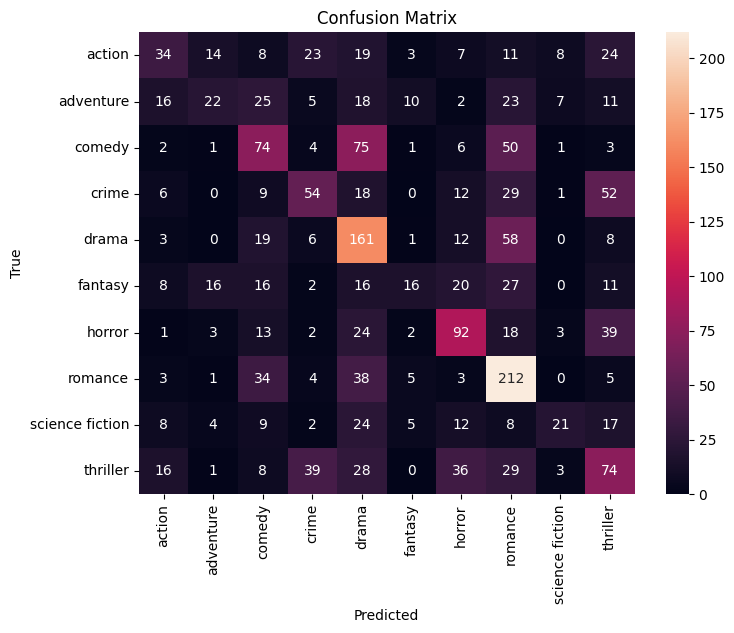

In [15]:
cm = confusion_matrix(y_test, y_pred, labels=sorted(data_filtered["label"].unique()))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=sorted(data_filtered["label"].unique()),
            yticklabels=sorted(data_filtered["label"].unique()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Single label model with reviews

In [16]:
import numpy as np


def combine_text(row):
    desc = row["Description"] if pd.notna(row["Description"]) else ""
    reviews = row["AllReviews"]
    if reviews is None:
        reviews = []
    reviews_text = " ".join(str(r) for r in reviews)

    return desc + " " + reviews_text


data_filtered["text"] = data_filtered.apply(combine_text, axis=1)
data_filtered.head()


,Title,Genres,Description,AllReviews,label,text
0,Shaun of the Dead,"Horror, Horror","Shaun lives a supremely uneventful life, which...",[this is what EVERY other zombie comedy ever i...,horror,"Shaun lives a supremely uneventful life, which..."
1,Before Sunset,Romance,"Nine years later, Jesse travels across Europe ...",[Turns out I've never had a conversation befor...,romance,"Nine years later, Jesse travels across Europe ..."
2,Kiki’s Delivery Service,Fantasy,"A young witch, on her mandatory year of indepe...",[pretty fucked up that i wasn't born a cartoon...,fantasy,"A young witch, on her mandatory year of indepe..."
3,Babygirl,Romance,A high-powered CEO puts her career and family ...,[there’s just no way antonio banderas is that ...,romance,A high-powered CEO puts her career and family ...
4,Suicide Squad,"Action, Adventure, Fantasy","From DC Comics comes the Suicide Squad, an ant...",[Isabelle Huppert did not come all the way fro...,action,"From DC Comics comes the Suicide Squad, an ant..."


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    data_filtered["text"], data_filtered["label"],
    test_size=0.2, random_state=42, stratify=data_filtered["label"]
)
tfidf = TfidfVectorizer(max_features=20000, stop_words="english", ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [18]:
from sklearn.metrics import f1_score

y_pred = clf.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
total = len(y_test)
correct = (y_test == y_pred).sum()
print(f"Accuracy: {acc:.4f} ({correct}/{total} correct)")

print(classification_report(y_test, y_pred, zero_division=0))


f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
print(f"F1 Macro: {f1_macro:.4f}, F1 Micro: {f1_micro:.4f}")


Accuracy: 0.4157 (804/1934 correct)
                 precision    recall  f1-score   support

         action       0.35      0.24      0.28       151
      adventure       0.32      0.16      0.21       139
         comedy       0.40      0.37      0.39       217
          crime       0.43      0.27      0.33       181
          drama       0.45      0.71      0.55       268
        fantasy       0.48      0.11      0.18       132
         horror       0.53      0.52      0.52       197
        romance       0.44      0.72      0.55       305
science fiction       0.43      0.18      0.26       110
       thriller       0.27      0.29      0.28       234

       accuracy                           0.42      1934
      macro avg       0.41      0.36      0.36      1934
   weighted avg       0.41      0.42      0.39      1934

F1 Macro: 0.3556, F1 Micro: 0.4157


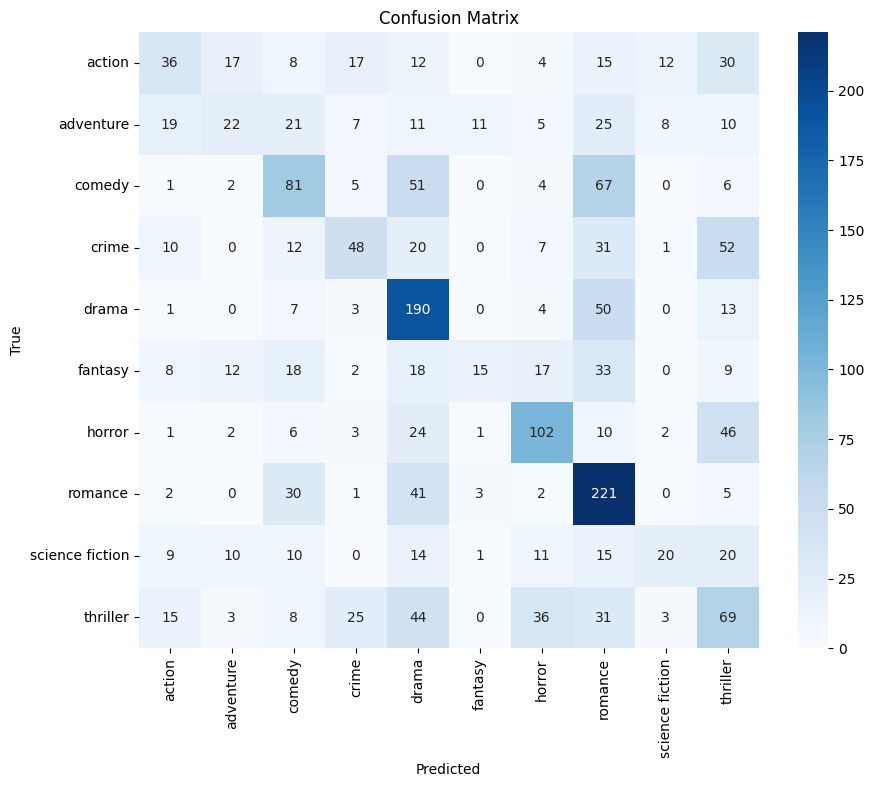

In [19]:
labels_for_cm = sorted(data_filtered["label"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_for_cm)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels_for_cm, yticklabels=labels_for_cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Multilabel

In [20]:
def remove_not_allowed_genres(genres):
    if pd.isna(genres):
        return []
    items = [g.strip() for g in genres.split(",")]
    filtered_items = [g for g in items if g in ALLOWED]
    return filtered_items

data_filtered["Genres_clean"] = data_filtered["Genres"].apply(remove_not_allowed_genres)
data_filtered = data_filtered[data_filtered["Genres_clean"].map(len) > 0]
data_filtered.head()


,Title,Genres,Description,AllReviews,label,text,Genres_clean
0,Shaun of the Dead,"Horror, Horror","Shaun lives a supremely uneventful life, which...",[this is what EVERY other zombie comedy ever i...,horror,"Shaun lives a supremely uneventful life, which...","[Horror, Horror]"
1,Before Sunset,Romance,"Nine years later, Jesse travels across Europe ...",[Turns out I've never had a conversation befor...,romance,"Nine years later, Jesse travels across Europe ...",[Romance]
2,Kiki’s Delivery Service,Fantasy,"A young witch, on her mandatory year of indepe...",[pretty fucked up that i wasn't born a cartoon...,fantasy,"A young witch, on her mandatory year of indepe...",[Fantasy]
3,Babygirl,Romance,A high-powered CEO puts her career and family ...,[there’s just no way antonio banderas is that ...,romance,A high-powered CEO puts her career and family ...,[Romance]
4,Suicide Squad,"Action, Adventure, Fantasy","From DC Comics comes the Suicide Squad, an ant...",[Isabelle Huppert did not come all the way fro...,action,"From DC Comics comes the Suicide Squad, an ant...","[Action, Adventure, Fantasy]"


In [21]:
from sklearn.preprocessing import MultiLabelBinarizer
all_genres = sorted({g for sublist in data_filtered["Genres_clean"] for g in sublist})
mlb = MultiLabelBinarizer(classes=all_genres)
Y = mlb.fit_transform(data_filtered["Genres_clean"])
X = data_filtered["Description"]



In [22]:
from sklearn.multiclass import OneVsRestClassifier

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(max_features=20000, stop_words="english", ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
clf.fit(X_train_tfidf, Y_train)

Y_pred = clf.predict(X_test_tfidf)

Y_prob = clf.predict_proba(X_test_tfidf)

Y_pred_fixed = np.where(Y_pred.sum(axis=1, keepdims=True)==0,
                        (Y_prob == Y_prob.max(axis=1, keepdims=True)).astype(int),
                        Y_pred)

pred_labels_fixed = mlb.inverse_transform(Y_pred_fixed)


In [23]:
from sklearn.metrics import hamming_loss

Y_pred = clf.predict(X_test_tfidf)

Y_prob = clf.predict_proba(X_test_tfidf)
Y_pred_fixed = np.where(Y_pred.sum(axis=1, keepdims=True) == 0,
                        (Y_prob == Y_prob.max(axis=1, keepdims=True)).astype(int),
                        Y_pred)

hl = hamming_loss(Y_test, Y_pred_fixed)
print("Hamming Loss:", hl)

f1_macro = f1_score(Y_test, Y_pred_fixed, average="macro", zero_division=0)
f1_micro = f1_score(Y_test, Y_pred_fixed, average="micro", zero_division=0)
print(f"F1 Macro: {f1_macro:.4f}, F1 Micro: {f1_micro:.4f}")

exact_match = np.all(Y_test == Y_pred_fixed, axis=1).mean()
print(f"Exact Match Accuracy: {exact_match:.4f}")


Hamming Loss: 0.14115822130299896
F1 Macro: 0.4327, F1 Micro: 0.4609
Exact Match Accuracy: 0.2580


In [24]:
pred_labels = mlb.inverse_transform(Y_pred_fixed)
true_labels = mlb.inverse_transform(Y_test)

for i in range(5):
    print("Text:", X_test.iloc[i][:100], "...")
    print("True:", true_labels[i])
    print("Pred:", pred_labels[i])
    print("---")

Text: Unveiled through a made-for-TV documentary, five chilling tales of found footage horror emerge to ta ...
True: ('Horror', 'Thriller')
Pred: ('Horror',)
---
Text: Bruce Banner, a genetics researcher with a tragic past, suffers massive radiation exposure in his la ...
True: ('Action', 'Adventure', 'Science Fiction')
Pred: ('Horror',)
---
Text: Emily Young, a senior, wants to be elected as her sorority’s president. She adopts a cute sloth, thi ...
True: ('Horror', 'Thriller')
Pred: ('Thriller',)
---
Text: Murphy is an American living in Paris who enters a highly sexually and emotionally charged relations ...
True: ('Romance',)
Pred: ('Romance',)
---
Text: Home with their newly-formed family, happy parents Dan and Jody are haunted by sinister, paranormal  ...
True: ('Comedy',)
Pred: ('Horror',)
---


In [25]:
genres = mlb.classes_

f1_per_genre = f1_score(Y_test, Y_pred_fixed, average=None, zero_division=0)

for genre, f1 in zip(genres, f1_per_genre):
    print(f"{genre}: F1 = {f1:.4f}")

sorted_f1 = sorted(zip(genres, f1_per_genre), key=lambda x: x[1], reverse=True)
print("\nTop 5 najlepiej przewidywanych gatunków:")
for genre, f1 in sorted_f1[:5]:
    print(f"{genre}: F1 = {f1:.4f}")

print("\nTop 5 najgorzej przewidywanych gatunków:")
for genre, f1 in sorted_f1[-5:]:
    print(f"{genre}: F1 = {f1:.4f}")


Action: F1 = 0.5000
Adventure: F1 = 0.4352
Comedy: F1 = 0.2543
Crime: F1 = 0.5164
Drama: F1 = 0.3879
Fantasy: F1 = 0.2473
Horror: F1 = 0.5570
Romance: F1 = 0.5762
Science Fiction: F1 = 0.4140
Thriller: F1 = 0.4382

Top 5 najlepiej przewidywanych gatunków:
Romance: F1 = 0.5762
Horror: F1 = 0.5570
Crime: F1 = 0.5164
Action: F1 = 0.5000
Thriller: F1 = 0.4382

Top 5 najgorzej przewidywanych gatunków:
Adventure: F1 = 0.4352
Science Fiction: F1 = 0.4140
Drama: F1 = 0.3879
Comedy: F1 = 0.2543
Fantasy: F1 = 0.2473


Multilabel model with reviews

In [26]:
Y = mlb.fit_transform(data_filtered["Genres_clean"])
X = data_filtered["text"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(max_features=20000, stop_words="english", ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
clf.fit(X_train_tfidf, Y_train)

Y_pred = clf.predict(X_test_tfidf)

Y_prob = clf.predict_proba(X_test_tfidf)

Y_pred_fixed = np.where(Y_pred.sum(axis=1, keepdims=True)==0,
                        (Y_prob == Y_prob.max(axis=1, keepdims=True)).astype(int),
                        Y_pred)

pred_labels_fixed = mlb.inverse_transform(Y_pred_fixed)

In [27]:
Y_pred = clf.predict(X_test_tfidf)

Y_prob = clf.predict_proba(X_test_tfidf)
Y_pred_fixed = np.where(Y_pred.sum(axis=1, keepdims=True) == 0,
                        (Y_prob == Y_prob.max(axis=1, keepdims=True)).astype(int),
                        Y_pred)

hl = hamming_loss(Y_test, Y_pred_fixed)
print("Hamming Loss:", hl)

f1_macro = f1_score(Y_test, Y_pred_fixed, average="macro", zero_division=0)
f1_micro = f1_score(Y_test, Y_pred_fixed, average="micro", zero_division=0)
print(f"F1 Macro: {f1_macro:.4f}, F1 Micro: {f1_micro:.4f}")

exact_match = np.all(Y_test == Y_pred_fixed, axis=1).mean()
print(f"Exact Match Accuracy: {exact_match:.4f}")

Hamming Loss: 0.1313340227507756
F1 Macro: 0.4612, F1 Micro: 0.4968
Exact Match Accuracy: 0.2958


In [28]:
pred_labels = mlb.inverse_transform(Y_pred_fixed)
true_labels = mlb.inverse_transform(Y_test)

for i in range(5):
    print("Text:", X_test.iloc[i][:100], "...")
    print("True:", true_labels[i])
    print("Pred:", pred_labels[i])
    print("---")

Text: Unveiled through a made-for-TV documentary, five chilling tales of found footage horror emerge to ta ...
True: ('Horror', 'Thriller')
Pred: ('Horror',)
---
Text: Bruce Banner, a genetics researcher with a tragic past, suffers massive radiation exposure in his la ...
True: ('Action', 'Adventure', 'Science Fiction')
Pred: ('Action',)
---
Text: Emily Young, a senior, wants to be elected as her sorority’s president. She adopts a cute sloth, thi ...
True: ('Horror', 'Thriller')
Pred: ('Comedy',)
---
Text: Murphy is an American living in Paris who enters a highly sexually and emotionally charged relations ...
True: ('Romance',)
Pred: ('Romance',)
---
Text: Home with their newly-formed family, happy parents Dan and Jody are haunted by sinister, paranormal  ...
True: ('Comedy',)
Pred: ('Horror',)
---


In [29]:
genres = mlb.classes_

f1_per_genre = f1_score(Y_test, Y_pred_fixed, average=None, zero_division=0)

for genre, f1 in zip(genres, f1_per_genre):
    print(f"{genre}: F1 = {f1:.4f}")

sorted_f1 = sorted(zip(genres, f1_per_genre), key=lambda x: x[1], reverse=True)
print("\nTop 5 najlepiej przewidywanych gatunków:")
for genre, f1 in sorted_f1[:5]:
    print(f"{genre}: F1 = {f1:.4f}")

print("\nTop 5 najgorzej przewidywanych gatunków:")
for genre, f1 in sorted_f1[-5:]:
    print(f"{genre}: F1 = {f1:.4f}")


Action: F1 = 0.5415
Adventure: F1 = 0.3915
Comedy: F1 = 0.2847
Crime: F1 = 0.4691
Drama: F1 = 0.4813
Fantasy: F1 = 0.2509
Horror: F1 = 0.6678
Romance: F1 = 0.5787
Science Fiction: F1 = 0.4336
Thriller: F1 = 0.5130

Top 5 najlepiej przewidywanych gatunków:
Horror: F1 = 0.6678
Romance: F1 = 0.5787
Action: F1 = 0.5415
Thriller: F1 = 0.5130
Drama: F1 = 0.4813

Top 5 najgorzej przewidywanych gatunków:
Crime: F1 = 0.4691
Science Fiction: F1 = 0.4336
Adventure: F1 = 0.3915
Comedy: F1 = 0.2847
Fantasy: F1 = 0.2509


Transformer

In [33]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from transformers import AutoTokenizer, BertForSequenceClassification
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss
import matplotlib.pyplot as plt
import numpy as np

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(data_filtered["Genres_clean"])
X = data_filtered["text"].tolist()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_enc = tokenizer(X_train, truncation=True, padding="max_length", max_length=256)
test_enc  = tokenizer(X_test, truncation=True, padding="max_length", max_length=256)

train_dataset = TensorDataset(
    torch.tensor(train_enc["input_ids"]),
    torch.tensor(train_enc["attention_mask"]),
    torch.tensor(Y_train, dtype=torch.float)
)

test_dataset = TensorDataset(
    torch.tensor(test_enc["input_ids"]),
    torch.tensor(test_enc["attention_mask"]),
    torch.tensor(Y_test, dtype=torch.float)
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=Y.shape[1],
    problem_type="multi_label_classification"
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()

def train_epoch():
    model.train()
    total_loss = 0
    for input_ids, attention_mask, labels in train_loader:
        optimizer.zero_grad()
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def evaluate():
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for input_ids, attention_mask, labels in test_loader:
            outputs = model(
                input_ids=input_ids.to(device),
                attention_mask=attention_mask.to(device)
            )
            preds = (torch.sigmoid(outputs.logits).cpu().numpy() > 0.5)
            all_pred.append(preds)
            all_true.append(labels.numpy())

    y_true = np.vstack(all_true)
    y_pred = np.vstack(all_pred)
    metrics = {
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred)
    }
    return metrics, y_pred

epochs = 10
patience = 2
best_f1 = 0
wait = 0

train_losses = []
f1_scores = []

for epoch in range(epochs):
    loss = train_epoch()
    metrics, _ = evaluate()
    train_losses.append(loss)
    f1_scores.append(metrics["f1_micro"])

    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | F1 Micro: {metrics['f1_micro']:.4f} | F1 Macro: {metrics['f1_macro']:.4f} | Hamming: {metrics['hamming_loss']:.4f}")

    if metrics["f1_micro"] > best_f1:
        best_f1 = metrics["f1_micro"]
        wait = 0
        best_model_state = model.state_dict()
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(best_model_state)
            break



Using device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/10 | Loss: 0.3334 | F1 Micro: 0.5909 | F1 Macro: 0.5478 | Hamming: 0.1104
Epoch 2/10 | Loss: 0.2306 | F1 Micro: 0.6352 | F1 Macro: 0.6160 | Hamming: 0.1103
Epoch 3/10 | Loss: 0.1696 | F1 Micro: 0.6266 | F1 Macro: 0.6094 | Hamming: 0.1124
Epoch 4/10 | Loss: 0.1161 | F1 Micro: 0.6492 | F1 Macro: 0.6343 | Hamming: 0.1080
Epoch 5/10 | Loss: 0.0813 | F1 Micro: 0.6356 | F1 Macro: 0.6177 | Hamming: 0.1126
Epoch 6/10 | Loss: 0.0559 | F1 Micro: 0.6428 | F1 Macro: 0.6349 | Hamming: 0.1100
Early stopping at epoch 6


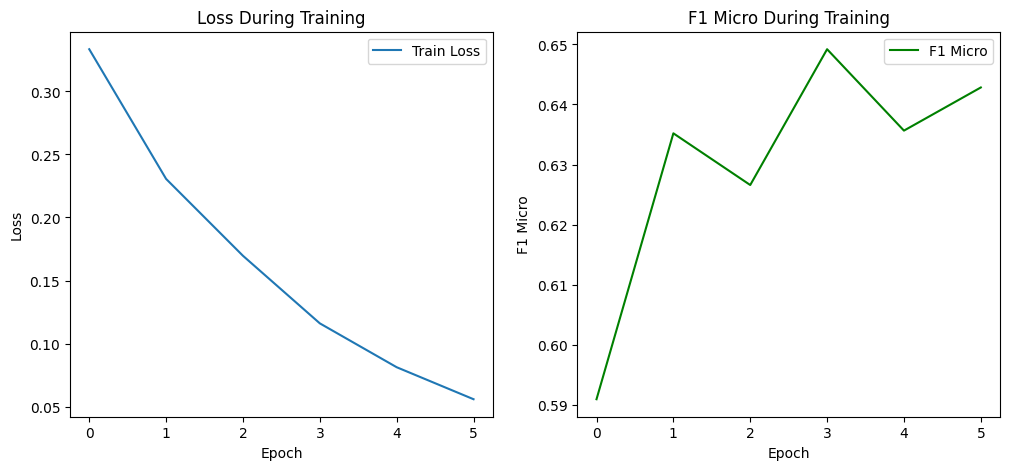


Final evaluation metrics: {'f1_micro': 0.6428331654917757, 'f1_macro': 0.6349275045981115, 'hamming_loss': 0.11003102378490176}
Text: Unveiled through a made-for-TV documentary, five chilling tales of fou ...
True: ('Horror', 'Thriller')
Pred: ('Horror', 'Thriller')
---
Text: Bruce Banner, a genetics researcher with a tragic past, suffers massiv ...
True: ('Action', 'Adventure', 'Science Fiction')
Pred: ('Action', 'Science Fiction')
---
Text: Emily Young, a senior, wants to be elected as her sorority’s president ...
True: ('Horror', 'Thriller')
Pred: ('Crime', 'Horror')
---
Text: Murphy is an American living in Paris who enters a highly sexually and ...
True: ('Romance',)
Pred: ('Romance', 'Thriller')
---
Text: Home with their newly-formed family, happy parents Dan and Jody are ha ...
True: ('Comedy',)
Pred: ('Horror',)
---


In [35]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss During Training")
plt.legend()

plt.subplot(1,2,2)
plt.plot(f1_scores, label="F1 Micro", color="green")
plt.xlabel("Epoch")
plt.ylabel("F1 Micro")
plt.title("F1 Micro During Training")
plt.legend()
plt.show()

metrics, Y_pred = evaluate()
print("\nFinal evaluation metrics:", metrics)

pred_labels = mlb.inverse_transform(Y_pred)
for i in range(5):
    true_label_array = np.array(Y_test[i]).reshape(1, -1)
    print("Text:", X_test[i][:70], "...")
    print("True:", mlb.inverse_transform(true_label_array)[0])
    print("Pred:", pred_labels[i])
    print("---")


In [36]:
from sklearn.metrics import multilabel_confusion_matrix

Y_test_array = np.array(Y_test)

mcm = multilabel_confusion_matrix(Y_test_array, Y_pred)

for idx, cm in enumerate(mcm):
    print(f"Label: {mlb.classes_[idx]}")
    print(cm)
    print("---")


Label: Action
[[1457  124]
 [  95  258]]
---
Label: Adventure
[[1573  111]
 [  99  151]]
---
Label: Comedy
[[1638   85]
 [ 111  100]]
---
Label: Crime
[[1467  121]
 [ 109  237]]
---
Label: Drama
[[1592  102]
 [ 109  131]]
---
Label: Fantasy
[[1634   70]
 [  98  132]]
---
Label: Horror
[[1521   56]
 [ 116  241]]
---
Label: Romance
[[1502   64]
 [ 181  187]]
---
Label: Science Fiction
[[1656   62]
 [  54  162]]
---
Label: Thriller
[[1257  221]
 [ 140  316]]
---


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

for i, label in enumerate(mlb.classes_):
    cm = confusion_matrix(Y_test[:, i], Y_pred[:, i])

    plt.figure(figsize=(3, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {label}")
    plt.xlabel("Predykcja")
    plt.ylabel("Prawda")
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

true_counts = np.sum(Y_test, axis=0)
pred_counts = np.sum(Y_pred, axis=0)

x = np.arange(len(mlb.classes_))

plt.figure(figsize=(12, 4))
plt.bar(x - 0.2, true_counts, width=0.4, label="True")
plt.bar(x + 0.2, pred_counts, width=0.4, label="Predicted")
plt.xticks(x, mlb.classes_, rotation=45, ha="right")
plt.title("True vs Predicted label counts")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
history = {"loss": [], "f1_micro": [], "f1_macro": []}

for epoch in range(epochs):
    loss = train_epoch(model, train_loader, optimizer)
    metrics, _ = evaluate(model, test_loader)

    history["loss"].append(loss)
    history["f1_micro"].append(metrics["f1_micro"])
    history["f1_macro"].append(metrics["f1_macro"])

    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Metrics: {metrics}")


In [ ]:
plt.figure(figsize=(12,4))
plt.plot(history["loss"], label="Loss")
plt.title("Loss per epoch")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(history["f1_micro"], label="F1 micro")
plt.plot(history["f1_macro"], label="F1 macro")
plt.title("F1 scores per epoch")
plt.legend()
plt.show()
